In [33]:
# 1- a) Importing important libraries for data cleaning 
#    b) Reading the csv file
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
dt = pd.read_csv('messy_ecommerce_sales_data.csv')

In [34]:
# 2- Checking whether the file is properly readable or not
print("<---The first 5 data--->")
print(dt.head(5).to_string())
print("<---The last 5 data--->")
print(dt.tail(5).to_string())

<---The first 5 data--->
   Order Date Product Name     Category Region  Quantity   Sales  Profit
0  31-12-2024      Printer       Office    NaN       NaN  3640.0  348.93
1  2022-11-27        Mouse  Accessories   East       NaN  1197.0  106.53
2  2022-05-11       Tablet  Electronics  South       5.0  5865.0  502.73
3  2024-03-16        Mouse          NaN  South       2.0   786.0  202.87
4  2022/09/10        Mouse  Accessories   West       1.0   509.0  103.28
<---The last 5 data--->
        Order Date Product Name     Category Region  Quantity    Sales   Profit
3495  Feb 15, 2023      Monitor  Accessories  North       4.0   4064.0   771.16
3496  Sep 18, 2022      Monitor  Accessories   East       1.0   1117.0   119.89
3497    2022-04-12       Laptop  Electronics  South       4.0    260.0    66.02
3498    01/18/2022      Printer       Office  South       3.0    222.0    50.28
3499    2024-11-01   Smartwatch  Electronics    NaN       9.0  10530.0  1777.32


In [35]:
# 3- Coutning of null attributes in each column
total_nulls = dt.isnull().sum()
print("Total null attributes in each column--->")
print(total_nulls)

Total null attributes in each column--->
Order Date      348
Product Name    177
Category        213
Region          186
Quantity        173
Sales           189
Profit          149
dtype: int64


In [36]:
# 4- Dropping all null attributes
dt.dropna(inplace=True)
print(dt.to_string())

        Order Date Product Name     Category Region  Quantity    Sales   Profit
2       2022-05-11       Tablet  Electronics  South       5.0   5865.0   502.73
4       2022/09/10        Mouse  Accessories   West       1.0    509.0   103.28
5       01-12-2023       Camera  Electronics   West       1.0    524.0   106.35
6     Oct 09, 2023   Headphones  Accessories  North       7.0   6167.0  1027.98
8       04/02/2022   Smartwatch  Electronics   East       9.0   5526.0   595.28
9       2024-10-22      Printer       Office  South       8.0    672.0   186.37
11      09/27/2022   Smartwatch  Electronics   East       2.0    502.0   137.40
12      2023-12-21       Tablet  Electronics  North       7.0   7462.0  2166.17
13      2024-02-03   Smartphone  Electronics   West       5.0   4205.0   585.29
14      10-10-2023       Camera  Electronics   West       1.0    570.0   138.54
15      10/16/2022   Headphones  Accessories   East       1.0    441.0   102.42
16      2022-05-15        Mouse  Accesso

In [37]:
# 5- Calculating the percentage of profit
for index, row in dt.iterrows():
    sales = row['Sales']
    profit = row['Profit']
    if sales > 0:
        dt.at[index, 'percentage'] = (profit / sales) * 100
    else:
        dt.at[index, 'percentage'] = None
print(dt.to_string())

        Order Date Product Name     Category Region  Quantity    Sales   Profit  percentage
2       2022-05-11       Tablet  Electronics  South       5.0   5865.0   502.73    8.571697
4       2022/09/10        Mouse  Accessories   West       1.0    509.0   103.28   20.290766
5       01-12-2023       Camera  Electronics   West       1.0    524.0   106.35   20.295802
6     Oct 09, 2023   Headphones  Accessories  North       7.0   6167.0  1027.98   16.669045
8       04/02/2022   Smartwatch  Electronics   East       9.0   5526.0   595.28   10.772349
9       2024-10-22      Printer       Office  South       8.0    672.0   186.37   27.733631
11      09/27/2022   Smartwatch  Electronics   East       2.0    502.0   137.40   27.370518
12      2023-12-21       Tablet  Electronics  North       7.0   7462.0  2166.17   29.029349
13      2024-02-03   Smartphone  Electronics   West       5.0   4205.0   585.29   13.918906
14      10-10-2023       Camera  Electronics   West       1.0    570.0   138.54 

In [38]:
# 6- Removing unnecessary data from 'Region' column
dt['Region'] = dt['Region'].replace(['?'],np.nan)
dt['Region'] = dt['Region'].fillna(dt['Region'].mode()[0])
print(dt['Region'])

2       South
4        West
5        West
6       North
8        East
        ...  
3494    North
3495    North
3496     East
3497    South
3498    South
Name: Region, Length: 2295, dtype: str


In [39]:
# 6- Cleaning date column
dt['Order Date'] = pd.to_datetime(dt['Order Date'], format='mixed')
dt['Order Date'] = dt['Order Date'].dt.strftime('%Y-%m-%d')
print(dt.to_string())

      Order Date Product Name     Category Region  Quantity    Sales   Profit  percentage
2     2022-05-11       Tablet  Electronics  South       5.0   5865.0   502.73    8.571697
4     2022-09-10        Mouse  Accessories   West       1.0    509.0   103.28   20.290766
5     2023-01-12       Camera  Electronics   West       1.0    524.0   106.35   20.295802
6     2023-10-09   Headphones  Accessories  North       7.0   6167.0  1027.98   16.669045
8     2022-04-02   Smartwatch  Electronics   East       9.0   5526.0   595.28   10.772349
9     2024-10-22      Printer       Office  South       8.0    672.0   186.37   27.733631
11    2022-09-27   Smartwatch  Electronics   East       2.0    502.0   137.40   27.370518
12    2023-12-21       Tablet  Electronics  North       7.0   7462.0  2166.17   29.029349
13    2024-02-03   Smartphone  Electronics   West       5.0   4205.0   585.29   13.918906
14    2023-10-10       Camera  Electronics   West       1.0    570.0   138.54   24.305263
15    2022

In [40]:
# 7- Giving new index to finally cleaned data
dt = dt.reset_index(drop=True)
dt.to_csv('C:/Users/DELL/OneDrive/Desktop/ASSIGNMENTS/Project 1/Cleaned_data.csv', index=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_11952\2732389525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales,x='Region',y='Sales',palette='pastel')


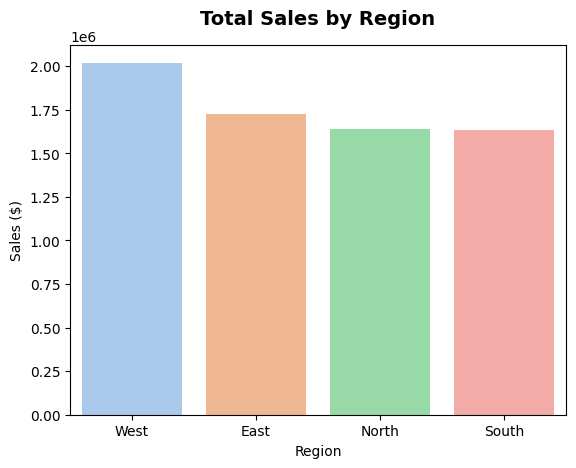

In [41]:
# 8- Geographic Comparison: Sales by Region (Bar Chart)
region_sales = dt.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=region_sales,x='Region',y='Sales',palette='pastel')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.show()